In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)

META_FEATURES = ["pred_dt", "pred_knn", "pred_rf"]
MODEL_PATH = "../_models/rf_stacking_search_result_2026_08_20_17_30_45.pkl"
TRAIN_PATH = "../_data/stacking_train_data.csv"
TEST_PATH = "../_data/stacking_test_data.csv"



In [2]:
stack_model = joblib.load(MODEL_PATH)

stacking_train = pd.read_csv(TRAIN_PATH)
stacking_test = pd.read_csv(TEST_PATH)

X_train = stacking_train[META_FEATURES]
y_train = stacking_train["Class"].astype(int)
X_test = stacking_test[META_FEATURES]
y_test = stacking_test["Class"].astype(int)

proba_train = stack_model.predict_proba(X_train)[:, 1]
proba_test = stack_model.predict_proba(X_test)[:, 1]

print("Loaded:", MODEL_PATH)
print("Best params:", getattr(stack_model, "best_params_", None))
print("Train:", X_train.shape, "fraud rate:", float(y_train.mean()))
print("Test:", X_test.shape, "fraud rate:", float(y_test.mean()))


Loaded: ../_models/rf_stacking_search_result_2026_08_20_17_30_45.pkl
Best params: {'n_estimators': 300, 'min_samples_split': 25, 'min_samples_leaf': 46, 'max_features': 1, 'max_depth': 20, 'criterion': 'entropy', 'class_weight': None, 'bootstrap': True}
Train: (227845, 3) fraud rate: 0.001729245759178389
Test: (56962, 3) fraud rate: 0.0017204452090867595


Default threshold 0.5 on test set
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.91      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



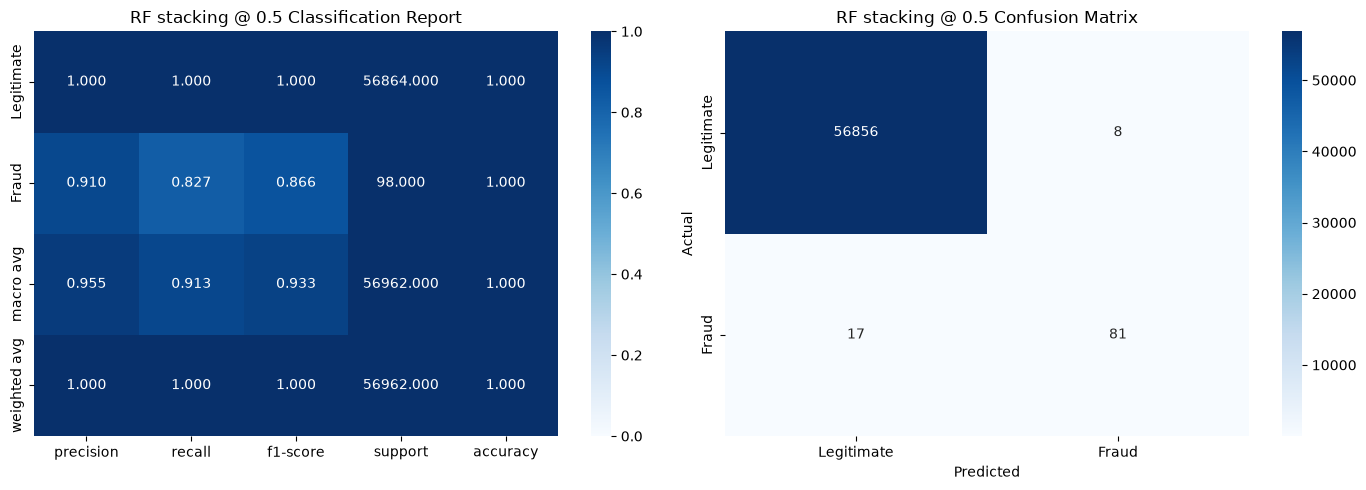

In [3]:
def predict_at_threshold(proba, threshold):
    return (proba >= threshold).astype(int)


def metrics_at_threshold(y_true, proba, threshold):
    y_pred = predict_at_threshold(proba, threshold)
    return {
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "tp": int(((y_true == 1) & (y_pred == 1)).sum()),
        "fn": int(((y_true == 1) & (y_pred == 0)).sum()),
        "fp": int(((y_true == 0) & (y_pred == 1)).sum()),
        "tn": int(((y_true == 0) & (y_pred == 0)).sum()),
    }


def plot_report_and_cm(y_true, y_pred, title):
    class_labels = ["Legitimate", "Fraud"]
    report_dict = classification_report(
        y_true, y_pred, target_names=class_labels, output_dict=True, zero_division=0
    )
    accuracy = report_dict.pop("accuracy")
    report_df = pd.DataFrame(report_dict).T
    report_df["accuracy"] = accuracy
    report_metrics = report_df[["precision", "recall", "f1-score", "support", "accuracy"]]
    cm = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(report_metrics, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, ax=axes[0])
    axes[0].set_title(f"{title} Classification Report")
    axes[0].set_ylabel("")

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axes[1],
    )
    axes[1].set_title(f"{title} Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    plt.tight_layout()
    plt.show()


print("Default threshold 0.5 on test set")
y_test_pred_default = predict_at_threshold(proba_test, 0.5)
print(classification_report(y_test, y_test_pred_default, target_names=["Legitimate", "Fraud"], zero_division=0))
plot_report_and_cm(y_test, y_test_pred_default, "RF stacking @ 0.5")


In [11]:
# Assignment thresholds plus a finer grid for recall-oriented tuning.
# Threshold is chosen on TRAIN (F2, which weights recall more than precision), then locked and scored on TEST.
required_thresholds = [0.3, 0.5, 0.7]
candidate_thresholds = np.unique(np.round(np.concatenate([
    np.linspace(0.05, 0.95, 19),
    required_thresholds,
]), 4))

train_rows = [metrics_at_threshold(y_train, proba_train, t) for t in candidate_thresholds]
train_thresh_df = pd.DataFrame(train_rows).sort_values("threshold").reset_index(drop=True)

best_f2_row = train_thresh_df.loc[train_thresh_df["f2"].idxmax()]
best_threshold = float(best_f2_row["threshold"])

print("Train threshold sweep (used only to pick the cutoff)")
display(train_thresh_df.round({
    "threshold": 2,
    "precision": 4,
    "recall": 4,
    "f1": 4,
    "f2": 4,
    "accuracy": 6,
}))
print(
    f"Selected threshold={best_threshold:.2f} "
    f"(train F2={best_f2_row['f2']:.4f}, recall={best_f2_row['recall']:.4f}, precision={best_f2_row['precision']:.4f})"
)


Train threshold sweep (used only to pick the cutoff)


,threshold,precision,recall,f1,f2,accuracy,tp,fn,fp,tn
0,0.05,0.6369,0.8503,0.7283,0.7969,0.998903,335,59,191,227260
1,0.10,0.7557,0.8401,0.7957,0.8217,0.999254,331,63,107,227344
2,0.15,0.7966,0.8350,0.8154,0.8270,0.999346,329,65,84,227367
3,0.20,0.8144,0.8350,0.8246,0.8308,0.999386,329,65,75,227376
4,0.25,0.8512,0.8274,0.8391,0.8321,0.999451,326,68,57,227394
5,0.30,0.8825,0.8198,0.8500,0.8316,0.999500,323,71,43,227408
6,0.35,0.8920,0.8173,0.8530,0.8312,0.999513,322,72,39,227412
7,0.40,0.9188,0.8046,0.8579,0.8251,0.999539,317,77,28,227423
8,0.45,0.9238,0.7995,0.8571,0.8216,0.999539,315,79,26,227425
9,0.50,0.9254,0.7868,0.8505,0.8111,0.999522,310,84,25,227426


Selected threshold=0.25 (train F2=0.8321, recall=0.8274, precision=0.8512)


Test set: required thresholds 0.3 / 0.5 / 0.7


,threshold,precision,recall,f1,tp,fn,fp
5,0.3,0.8485,0.8571,0.8528,84,14,15
9,0.5,0.9101,0.8265,0.8663,81,17,8
13,0.7,0.9733,0.7449,0.8439,73,25,2


Full test threshold sweep


,threshold,precision,recall,f1,f2,accuracy,tp,fn,fp,tn
0,0.05,0.5972,0.8776,0.7107,0.8022,0.998771,86,12,58,56806
1,0.10,0.6880,0.8776,0.7713,0.8317,0.999105,86,12,39,56825
2,0.15,0.7288,0.8776,0.7963,0.8431,0.999228,86,12,32,56832
3,0.20,0.7544,0.8776,0.8113,0.8498,0.999298,86,12,28,56836
4,0.25,0.8333,0.8673,0.8500,0.8603,0.999473,85,13,17,56847
5,0.30,0.8485,0.8571,0.8528,0.8554,0.999491,84,14,15,56849
6,0.35,0.8438,0.8265,0.8351,0.8299,0.999438,81,17,15,56849
7,0.40,0.9000,0.8265,0.8617,0.8402,0.999544,81,17,9,56855
8,0.45,0.9000,0.8265,0.8617,0.8402,0.999544,81,17,9,56855
9,0.50,0.9101,0.8265,0.8663,0.8420,0.999561,81,17,8,56856


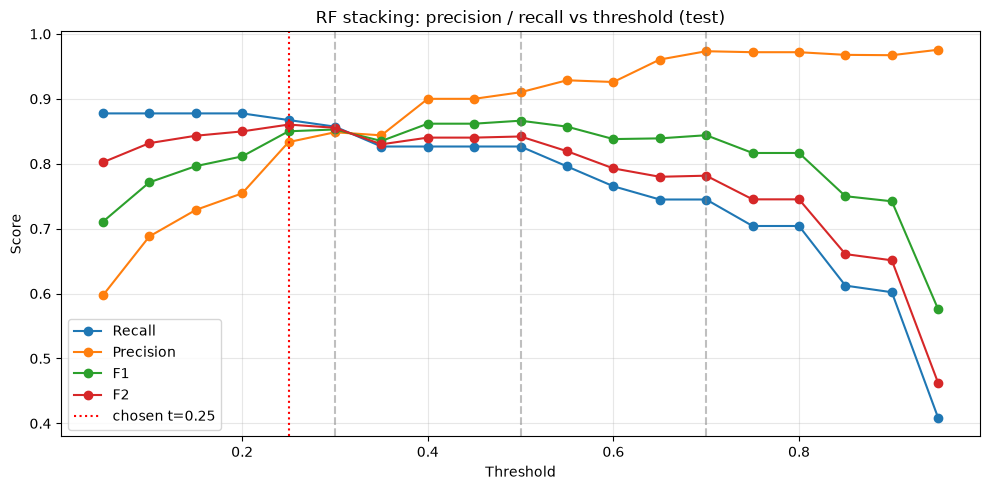

In [12]:
test_rows = [metrics_at_threshold(y_test, proba_test, t) for t in candidate_thresholds]
test_thresh_df = pd.DataFrame(test_rows).sort_values("threshold").reset_index(drop=True)

print("Test set: required thresholds 0.3 / 0.5 / 0.7")
display(
    test_thresh_df.loc[
        test_thresh_df["threshold"].isin(required_thresholds),
        ["threshold", "precision", "recall", "f1", "tp", "fn", "fp"],
    ].round({"threshold": 1, "precision": 4, "recall": 4, "f1": 4})
)

print("Full test threshold sweep")
display(test_thresh_df.round({
    "threshold": 2,
    "precision": 4,
    "recall": 4,
    "f1": 4,
    "f2": 4,
    "accuracy": 6,
}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_thresh_df["threshold"], test_thresh_df["recall"], marker="o", label="Recall")
ax.plot(test_thresh_df["threshold"], test_thresh_df["precision"], marker="o", label="Precision")
ax.plot(test_thresh_df["threshold"], test_thresh_df["f1"], marker="o", label="F1")
ax.plot(test_thresh_df["threshold"], test_thresh_df["f2"], marker="o", label="F2")
for t in required_thresholds:
    ax.axvline(t, color="gray", linestyle="--", alpha=0.5)
ax.axvline(best_threshold, color="red", linestyle=":", label=f"chosen t={best_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("RF stacking: precision / recall vs threshold (test)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Tuned threshold 0.25 on test set
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.87      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



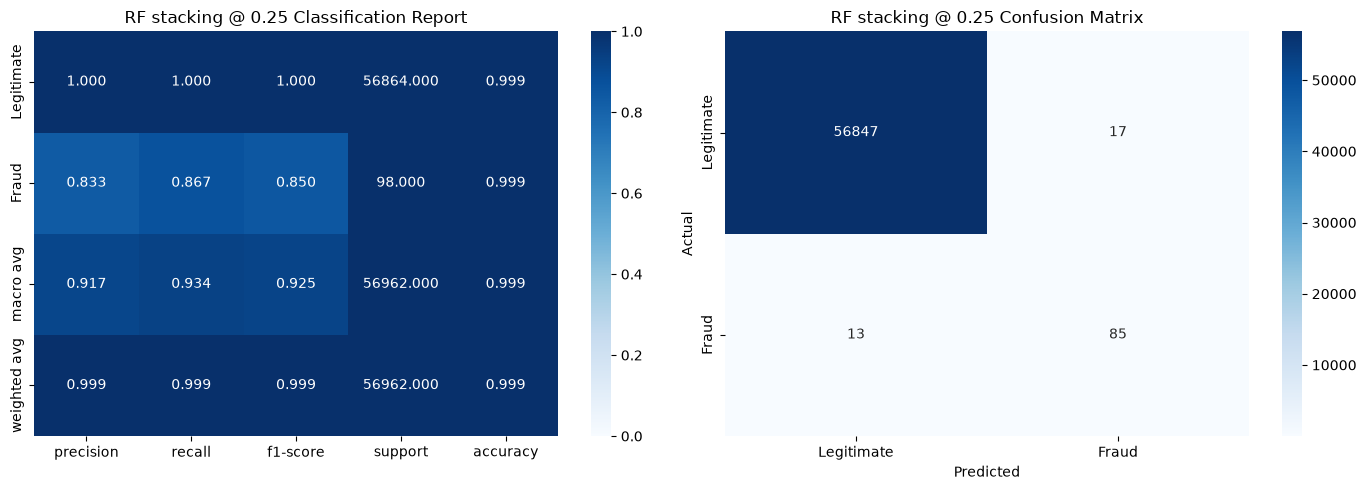

,setting,threshold,precision,recall,f1,f2,tp,fn,fp
0,default 0.5,0.50,0.9101,0.8265,0.8663,0.8420,81,17,8
1,tuned 0.25,0.25,0.8333,0.8673,0.8500,0.8603,85,13,17


In [13]:
print(f"Tuned threshold {best_threshold:.2f} on test set")
y_test_pred_tuned = predict_at_threshold(proba_test, best_threshold)
print(classification_report(y_test, y_test_pred_tuned, target_names=["Legitimate", "Fraud"], zero_division=0))
plot_report_and_cm(y_test, y_test_pred_tuned, f"RF stacking @ {best_threshold:.2f}")

default_row = metrics_at_threshold(y_test, proba_test, 0.5)
tuned_row = metrics_at_threshold(y_test, proba_test, best_threshold)
compare_df = pd.DataFrame([default_row, tuned_row])
compare_df.insert(0, "setting", ["default 0.5", f"tuned {best_threshold:.2f}"])
display(
    compare_df[["setting", "threshold", "precision", "recall", "f1", "f2", "tp", "fn", "fp"]].round({
        "threshold": 2,
        "precision": 4,
        "recall": 4,
        "f1": 4,
        "f2": 4,
    })
)


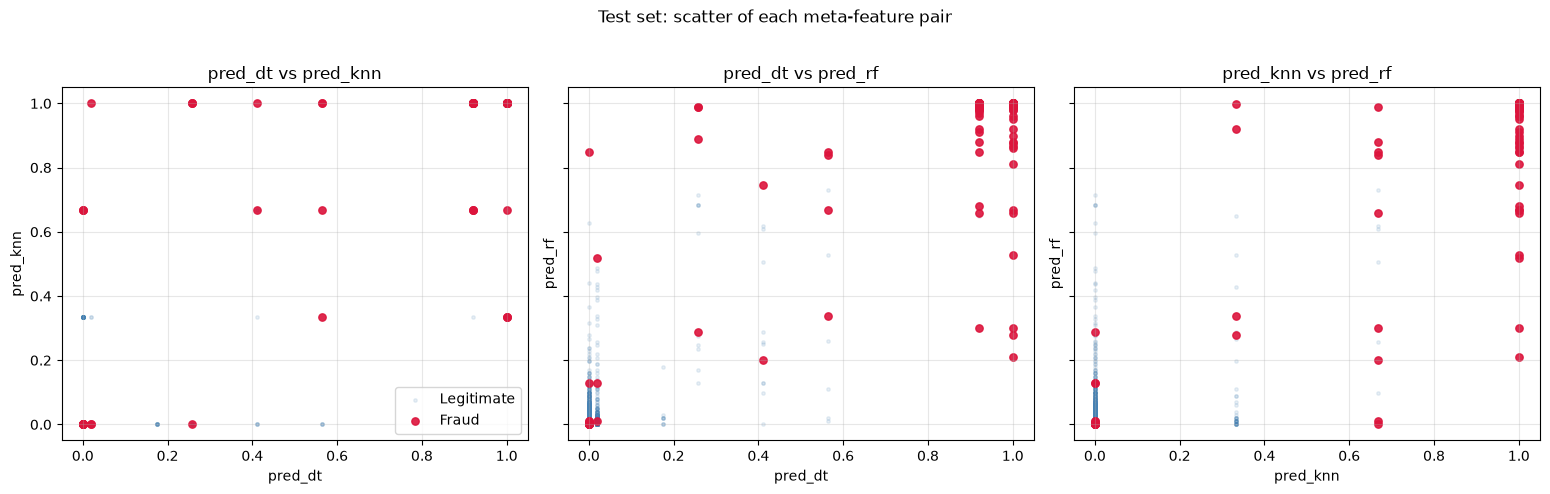

In [21]:
from itertools import combinations

legit = stacking_test[stacking_test["Class"] == 0]
fraud = stacking_test[stacking_test["Class"] == 1]
pairs = list(combinations(META_FEATURES, 2))

fig, axes = plt.subplots(1, len(pairs), figsize=(5.2 * len(pairs), 4.8), sharex=True, sharey=True)
for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(legit[x_col], legit[y_col], s=6, alpha=0.12, c="steelblue", label="Legitimate")
    ax.scatter(fraud[x_col], fraud[y_col], s=28, alpha=0.9, c="crimson", label="Fraud")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.grid(True, alpha=0.3)

axes[0].legend()
fig.suptitle("Test set: scatter of each meta-feature pair", y=1.02)
plt.tight_layout()
plt.show()